# Feature Engineering: Microstructure, Technicals, and Scaling
**Objective:** Transform raw, non-stationary market data into a highly stationary, multi-dimensional state space. We will apply the technical and microstructure modules, generate our raw volatility targets, and enforce strict, zero-lookahead Train/Validation splitting before scaling.

In [9]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add the src directory to the Python path
sys.path.append(os.path.abspath('../src'))

from data_pipeline.preprocessor import MarketDataPreprocessor
from features.technicals import TechnicalFeatures
from features.microstructure import MicrostructureFeatures

# Plotting configuration
plt.style.use('dark_background')
sns.set_palette("bright")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.2

## 1. Pipeline Initialization & Base Preprocessing
First, we load the raw 2024-2025 dataset and pass it through the foundational time-grid and log-return calculations.

In [12]:
preprocessor = MarketDataPreprocessor()
raw_path = '../data/raw/ETHUSDT_5m_2024-01-01_to_2026-01-01.csv'

if not os.path.exists(raw_path):
    print(f"Data not found at {raw_path}. Run fetch_binance.py first.")
else:
    df_raw = pd.read_csv(raw_path, index_col=0, parse_dates=True)
    
    # Force grid and compute returns
    df_base = preprocessor.force_time_grid(df_raw, interval='5min')
    df_base = preprocessor.compute_log_returns(df_base)
    
    print(f"Base Preprocessing Complete. Shape: {df_base.shape}")

2026-06-22 01:47:58,276 - INFO - Forcing continuous time grid...
2026-06-22 01:47:58,281 - INFO - Grid fill complete. Final shape: (210529, 9)
2026-06-22 01:47:58,282 - INFO - Computing Log Returns...


Base Preprocessing Complete. Shape: (210528, 11)


## 2. Generating the Feature Matrix
We will now use our modular classes to build the quantitative features.
1. **Technicals:** HAR volatility memory, Garman-Klass, Momentum, and Sin/Cos Time.
2. **Microstructure:** Amihud Illiquidity, Whale Tracker (Z-Scores), Volume Imbalance.

In [13]:
# Initialize feature builders
tech_builder = TechnicalFeatures(bars_per_day=288)
micro_builder = MicrostructureFeatures()

print("Generating Technical Features...")
df_features = tech_builder.generate_all(df_base, drop_nans=False)

print("Generating Microstructure Features...")
df_features = micro_builder.generate_all(df_features)

# Drop NaNs here to remove the 1-week warm-up period required for the HAR 'rv_1w' feature
initial_len = len(df_features)
df_features.dropna(inplace=True)
print(f"Feature Generation Complete. Dropped {initial_len - len(df_features)} warm-up rows.")
print(f"Current Shape: {df_features.shape}")

2026-06-22 01:48:16,443 - INFO - Computing HAR Volatility lags (1h, 1d, 1w)...


2026-06-22 01:48:16,452 - INFO - Computing Garman-Klass Volatility...
2026-06-22 01:48:16,455 - INFO - Computing RSI and EMA Ratio...
2026-06-22 01:48:16,463 - INFO - Computing Sin/Cos seasonality encodings...
2026-06-22 01:48:16,485 - INFO - Computing Whale Tracker features...
2026-06-22 01:48:16,490 - INFO - Computing Amihud Illiquidity...
2026-06-22 01:48:16,491 - INFO - Computing Volume Imbalance...
2026-06-22 01:48:16,492 - INFO - Computing Volatility-to-Volume Ratio...


Generating Technical Features...
Generating Microstructure Features...
Feature Generation Complete. Dropped 2015 warm-up rows.
Current Shape: (208513, 26)


## 3. Visualizing Microstructure (Whale Tracker & Illiquidity)
Let's verify that our engineered features successfully capture the hidden mechanics of the market. We'll plot a short slice of the Amihud Illiquidity against raw price returns to see how it flags "fragile" price movements.

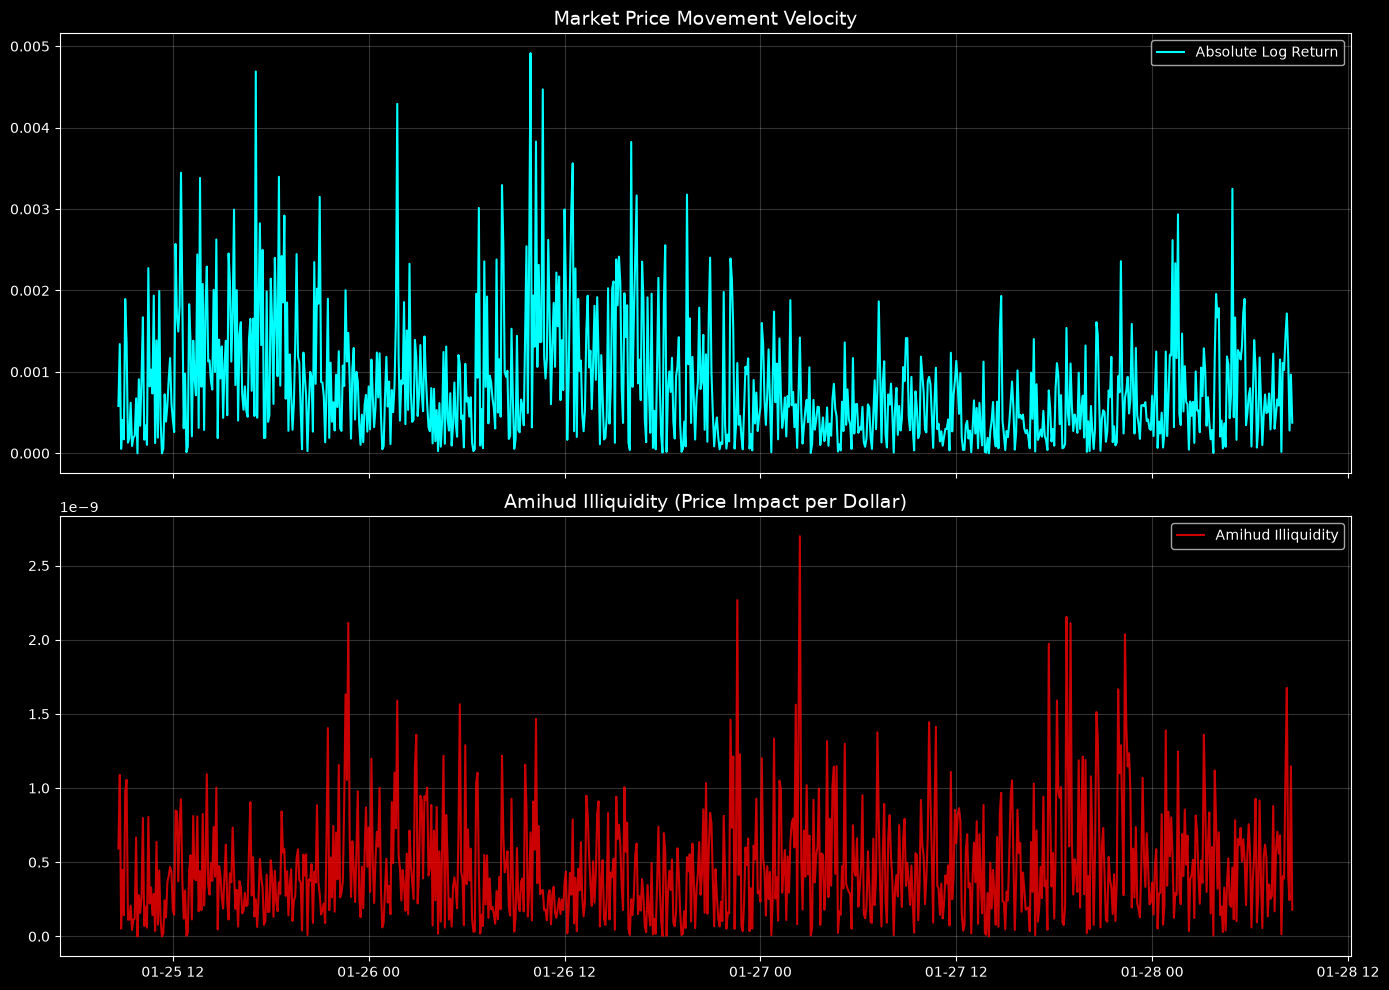

In [14]:
# Take a 3-day slice for clear visualization
slice_df = df_features.iloc[5000:5864]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot 1: Absolute Log Returns
ax1.plot(slice_df.index, slice_df['log_return'].abs(), color='cyan', label='Absolute Log Return')
ax1.set_title('Market Price Movement Velocity', fontsize=14)
ax1.legend()

# Plot 2: Amihud Illiquidity
ax2.plot(slice_df.index, slice_df['amihud_illiquidity'], color='red', alpha=0.8, label='Amihud Illiquidity')
ax2.set_title('Amihud Illiquidity (Price Impact per Dollar)', fontsize=14)
ax2.legend()

plt.tight_layout()
plt.show()

## 4. Target Variable Calculation (Pre-Scaling)
**CRITICAL FIX:** We must calculate the target variable (Next-Day Realized Volatility) *before* applying the StandardScaler. If we scale first, the model will learn scaled variance, breaking the raw volatility constraints required by the strategy engine and the QLIKE loss function.

In [15]:
def compute_target(df: pd.DataFrame, bars_per_day: int = 288) -> pd.DataFrame:
    """Computes raw next day realized volatility (no log scale)."""
    # Sum squared returns over the NEXT 288 bars
    r2 = df['log_return'] ** 2
    fwd_var = r2.rolling(window=bars_per_day).sum().shift(-bars_per_day)
    
    # Calculate Raw RV
    df['target_rv_next'] = np.sqrt(fwd_var)
    
    # Drop the trailing 288 bars which will have NaN targets
    return df.dropna()

print("Computing Targets on raw data...")
df_features = compute_target(df_features)
print(f"Target calculated. Current Shape: {df_features.shape}")

Computing Targets on raw data...
Target calculated. Current Shape: (208225, 27)


## 5. Strict Train / Validation Split & Scaling
As outlined in the architecture spec, we must split our data **by time**. 
* **Train:** Jun 2024 – Aug 2025
* **Validation:** Sep 2025 – Dec 2025
* *(Test is 2026, locked away)*

We fit the `StandardScaler` **STRICTLY ON THE TRAIN SET** to prevent data leakage, and we strictly ensure the target variable is **not** included in the scaling list.

In [16]:
# 1. Define the split date
split_date = '2025-08-31 23:59:59'

train_df = df_features.loc[:split_date].copy()
val_df = df_features.loc['2025-09-01':].copy()

print(f"Train Set Shape: {train_df.shape}")
print(f"Val Set Shape:   {val_df.shape}")

# 2. Define features to scale (EXCLUDE 'target_rv_next' and time encodings)
features_to_scale = [
    'log_return', 'log_volume_usdt', 'rv_1h', 'rv_1d', 'rv_1w', 
    'garman_klass_vol', 'rsi_14', 'ema_ratio', 'avg_trade_size', 
    'volume_z_score', 'amihud_illiquidity', 'vol_imbalance', 'vol_to_vol_ratio'
]

# 3. Fit & Transform Train
train_scaled = preprocessor.fit_transform_scaler(train_df, features_to_scale)

# 4. Transform Validation (Using Train Scaler)
val_scaled = preprocessor.transform_scaler(val_df, features_to_scale)

print("\n--- Scaling Verification ---")
print("Train Mean (Should be ~0.0):")
print(train_scaled[features_to_scale].mean().head(3))
print("\nValidation Mean (Should NOT be exactly 0.0, as it reflects regime shifts):")
print(val_scaled[features_to_scale].mean().head(3))

# Quick sanity check on the target distribution
print(f"\nAverage Target Volatility in Train: {train_scaled['target_rv_next'].mean():.4f}")

2026-06-22 01:49:12,543 - INFO - Fitting and applying StandardScaler (Training Mode)...
2026-06-22 01:49:12,571 - INFO - Applying StandardScaler (Inference/Test Mode)...


Train Set Shape: (173376, 27)
Val Set Shape:   (34849, 27)

--- Scaling Verification ---
Train Mean (Should be ~0.0):
log_return        -1.311448e-18
log_volume_usdt   -1.028176e-15
rv_1h             -3.147476e-17
dtype: float64

Validation Mean (Should NOT be exactly 0.0, as it reflects regime shifts):
log_return        -0.007153
log_volume_usdt    0.191990
rv_1h             -0.034915
dtype: float64

Average Target Volatility in Train: 0.0329


## 6. Export to Processed Data
We save these clean, scaled datasets to the `data/processed/` folder so `03_train_volatility.ipynb` and `04_train_regime.ipynb` can load them directly.

In [17]:
# Ensure directory exists
os.makedirs('../data/processed', exist_ok=True)

# Save to disk
train_scaled.to_csv('../data/processed/train_engineered.csv')
val_scaled.to_csv('../data/processed/val_engineered.csv')

print(f"Saved Train Set: {train_scaled.shape}")
print(f"Saved Val Set:   {val_scaled.shape}")
print("Feature Engineering Pipeline Complete. Data is ready for modeling.")

Saved Train Set: (173376, 27)
Saved Val Set:   (34849, 27)
Feature Engineering Pipeline Complete. Data is ready for modeling.
